In [4]:
import sys

import pandas as pd

sys.path.append("..")


from utils.gloer_tools import (
    exog_gloer,
    load_gloer,
    weather_gloer,
    make_model_hp_list,
    build_gloer_exog,
    prep_for_analysis
)
from statsmodels.tsa.deterministic import Fourier
from functools import reduce
import matplotlib.pyplot as plt
import pickle
import numpy as np

from utils.filters import custom_fourier_terms, detrend_via_model, fit_sin, sinfunc, decompose_data

In [5]:
direction = "VERTICAL"
data, meta = load_gloer(remove_last_year=False, interpolate_endog=False)
stau, sicker = exog_gloer()
weather = weather_gloer()
d = (data[direction] - data[direction].min()) / (data[direction].max() - data[direction].min())
deseasoned, seasonality, trend = decompose_data(d)


NameError: name 'dl_to_raw_ts_new' is not defined

In [3]:
print(data.keys())
key = list(data.keys())[1]


dict_keys(['ASCE_015_06', 'ASCE_088_03', 'VERTICAL', 'DESC_139_08', 'EASTWEST', 'DESC_037_04', 'DESC_139_07', 'ASCE_088_02'])


In [23]:
stack = []
for key in data.keys():
    exog = build_gloer_exog(
        data[key],
        stau,
        weather,
        weather_variables=["temperature"],
        fourier_order=0,
        external_timesteps=[[0],[0]],
        mean_period=[3,3],
    )
    exog = exog.drop_duplicates()
    exog = exog[:150]
    d = data[key][:150]
    exog = (exog - exog.min()) / (exog.max() - exog.min())
    d = (d - d.min()) / (d.max() -d.min())
    #d.interpolate().plot()
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error
    poly = PolynomialFeatures(interaction_only=True,include_bias = False)
    interaction = poly.fit_transform(exog[["temperature_0", "W_0"]].interpolate().values)
    base = exog[["temperature_0", "W_0"]].interpolate().values

    for x in range(len(d.columns)):

        clf = LinearRegression()
        res = clf.fit(interaction[1:150], d.interpolate().values[1:150,x])

        clf2 = LinearRegression()
        res2 = clf2.fit(base[1:150], d.interpolate().values[1:150,x])


        a = mean_squared_error(d.interpolate().values[1:150,x],res2.predict(base[1:150]))
        b = mean_squared_error(d.interpolate().values[1:150,x],res.predict(interaction[1:150]))
        stack.append(a-b)

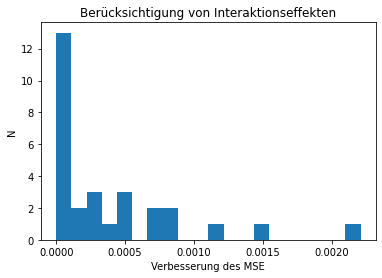

In [33]:
plt.hist(stack, bins=20)
plt.title("Berücksichtigung von Interaktionseffekten")
plt.xlabel("Verbesserung des MSE")
plt.ylabel("N")
plt.savefig("effects.png", dpi=300)

In [4]:
exog = build_gloer_exog(
        data[key],
        stau,
        weather,
        weather_variables=["temperature"],
        fourier_order=0,
        external_timesteps=[[0],[0]],
        mean_period=[3,3],
    )
exog = exog.drop_duplicates()
d = data[key]
exog = (exog - exog.min()) / (exog.max() - exog.min())
d = (d - d.min()) / (d.max() -d.min())

In [16]:
key

'ASCE_088_03'

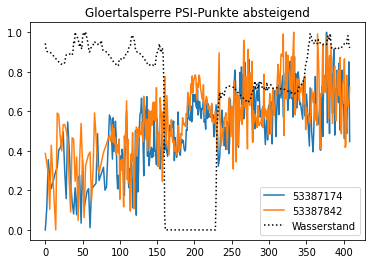

In [21]:
plt.plot(d.interpolate().values, label = d.columns)
plt.plot(exog["W_0"].values, color="black", label= "Wasserstand", linestyle="dotted")
plt.legend()
plt.title("Gloertalsperre PSI-Punkte absteigend")
plt.savefig("gloer.png", dpi=300)

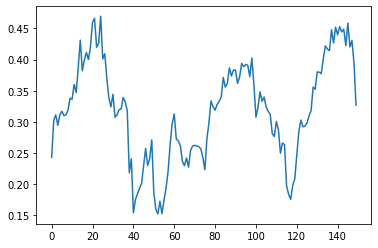

In [82]:
plt.plot(res.predict(interaction[:150]))

Text(0.5, 0.92, 'Ascending')

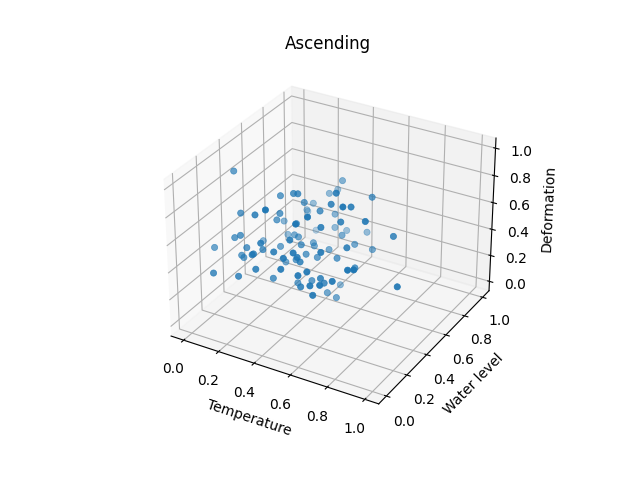

In [144]:
%matplotlib widget


X = exog["temperature_0"].values[:150]
Y = exog["W_0"].values[:150]
Z = d.values[:150,0]


ax = plt.axes(projection='3d')
ax.scatter(X,Y,Z, cmap='viridis', linewidth=0.5)
ax.set_ylabel("Water level")
ax.set_xlabel("Temperature")
ax.set_zlabel("Deformation")
ax.set_title("Ascending")


In [25]:
exog

,temperature_0,"temperature_mean_[3, 3]_0",W_0,"W_mean_[3, 3]_0"
date,,,,
2015-04-01,0.329787,0.376902,0.927750,0.913895
2015-04-07,0.404255,0.376007,0.947455,0.950308
2015-04-13,0.478723,0.506714,0.922414,0.927721
2015-04-19,0.476064,0.447628,0.901067,0.901711
2015-04-25,0.579787,0.569382,0.899836,0.900205
...,...,...,...,...
2021-12-07,0.300532,0.307073,0.978654,0.979055
2021-12-13,0.444149,0.358997,0.978654,0.979055
2021-12-19,0.375000,0.393912,0.924343,0.927173


In [27]:
exog

,sin_order_1,cos_order_1,sin_order_2,cos_order_2,temperature_1,"temperature_mean_[6, 6]_0",W_1,"W_mean_[6, 6]_0"
date,,,,,,,,
2015-04-04,0.382308,0.860480,0.871530,0.620228,7.7,3.733333,305.970,306.703333
2015-04-10,0.419832,0.872984,0.885296,0.542446,3.2,7.033333,307.240,307.065000
2015-04-16,0.458479,0.881396,0.882177,0.463517,13.6,10.583333,306.840,306.440000
2015-04-22,0.497805,0.885620,0.862316,0.387063,10.0,8.200000,306.120,305.988333
2015-04-28,0.537358,0.885606,0.826625,0.316595,6.4,9.450000,305.970,305.963333
...,...,...,...,...,...,...,...,...
2021-12-04,0.240990,0.273536,0.311396,0.211728,0.3,1.950000,306.950,307.404500
2021-12-10,0.216452,0.304556,0.251001,0.262639,1.8,1.433333,307.880,307.880000
2021-12-16,0.195377,0.338026,0.202836,0.325247,0.8,4.700000,307.880,307.337167


In [6]:
fourier_gen = Fourier(365.2422, order=1)
    # just use weather now since it start directily at 1.1.
fourier = fourier_gen.in_sample(np.arange(1,366))

In [85]:
a.min()

-0.9999993087345855

In [26]:
fourier_gen = Fourier(365.2422, order=1)
fourier = fourier_gen.in_sample(np.arange(1,366))
a = fourier["sin(1,365.24)"]
a = (a - a.min()) / (a.max() - a.min())


In [27]:
fourier

,"sin(1,365.24)","cos(1,365.24)"
1,0.000000,1.000000
2,0.017202,0.999852
3,0.034399,0.999408
4,0.051585,0.998669
5,0.068757,0.997633
...,...,...
361,-0.090058,0.995936
362,-0.072913,0.997338
363,-0.055746,0.998445
364,-0.038563,0.999256


In [8]:
from utils.filters import fit_sin, sinfunc, cosfunc

In [9]:
exog = (exog - exog.min()) / (exog.max() - exog.min())

In [11]:
weather.date = weather.date.dt.day_of_year

AttributeError: Can only use .dt accessor with datetimelike values

In [14]:
raw = weather.groupby("date").mean()["temperature"].values

In [15]:
raw = (raw - raw.min()) / (raw.max() - raw.min())


In [16]:
A,w,p,c = fit_sin(raw,fixed_freq=365.24219)["rawres"]

In [17]:
fit_sin(raw,fixed_freq=365.24219)["rawres"]

(0.3686873080360867, 0.01788839238239811, -2.03893684817126, 0.517456315778852)

In [164]:
raw = (weather - weather.min()) / (weather.max() - weather.min())

In [172]:
weather["date"].dt.day_of_year.values

array([  1,   2,   3, ..., 362, 363, 364])

In [178]:
weather

,date,station_id,daily_quality_level_3,wind_gust_max,wind_velocity_mean,daily_quality_level_4,precipitation_height,precipitation_form,sunshine_duration,snow_depth,...,temperature,humidity,temperature_max_200,temperature_min_200,temperature_min_005,soil_temperature_quality_level,soil_temperature_005,soil_temperature_010,soil_temperature_020,soil_temperature_050
0,2015-01-01,3098,10,13.2,3.6,9,0.7,4,6.500,0.0,...,1.2,88.00,2.8,0.2,-1.0,3,1.1,1.6,2.1,4.2
1,2015-01-02,3098,10,14.2,6.0,9,6.9,4,1.600,0.0,...,2.7,84.00,5.9,0.8,-0.8,3,1.5,1.8,2.2,4.1
2,2015-01-03,3098,10,9.8,3.8,9,3.8,4,0.000,0.0,...,0.6,94.00,1.3,0.1,-1.6,3,0.8,1.4,2.1,4.1
3,2015-01-04,3098,10,10.4,3.8,9,0.0,4,0.900,0.0,...,1.7,91.00,3.1,0.0,-1.4,3,1.0,1.4,1.9,4.0
4,2015-01-05,3098,10,10.0,3.8,9,0.0,0,3.100,0.0,...,0.9,89.00,2.6,0.2,-1.5,3,1.4,1.8,2.2,3.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2551,2021-12-26,3098,10,5.9,2.0,3,0.4,6,0.200,3.0,...,-0.2,92.25,1.9,-3.1,-3.7,3,1.0,1.4,2.1,4.3
2552,2021-12-27,3098,10,9.1,2.3,3,0.6,6,0.117,0.0,...,4.2,96.00,6.3,1.6,1.4,3,3.3,3.2,3.0,4.2
2553,2021-12-28,3098,10,19.8,4.2,3,20.2,6,0.000,0.0,...,6.7,93.71,8.1,4.8,4.2,3,5.1,4.9,4.5,4.6
2554,2021-12-29,3098,10,13.2,5.0,3,9.1,6,0.000,0.0,...,7.3,96.50,10.7,6.1,5.8,3,6.1,5.9,5.4,5.1


In [177]:
custom_fourier_terms(weather, order=1)

,sin_order_1,cos_order_1
date,,
0,0.188436,0.351094
1,0.185513,0.357006
2,0.182696,0.362970
3,0.179987,0.368982
4,0.177385,0.375043
...,...,...
359,0.168590,0.398198
360,0.166513,0.404457
361,0.164548,0.410752


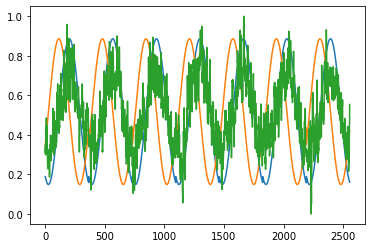

In [175]:
plt.plot(custom_fourier_terms(weather, order=1).values)
plt.plot(raw["temperature"])


In [176]:
custom_fourier_terms(weather, order=1)

,sin_order_1,cos_order_1
date,,
0,0.188436,0.351094
1,0.185513,0.357006
2,0.182696,0.362970
3,0.179987,0.368982
4,0.177385,0.375043
...,...,...
359,0.168590,0.398198
360,0.166513,0.404457
361,0.164548,0.410752


In [119]:
weather["date"][350:400].dt.day_of_year

350    351
351    352
352    353
353    354
354    355
355    356
356    357
357    358
358    359
359    360
360    361
361    362
362    363
363    364
364    365
365      1
366      2
367      3
368      4
369      5
370      6
371      7
372      8
373      9
374     10
375     11
376     12
377     13
378     14
379     15
380     16
381     17
382     18
383     19
384     20
385     21
386     22
387     23
388     24
389     25
390     26
391     27
392     28
393     29
394     30
395     31
396     32
397     33
398     34
399     35
Name: date, dtype: int64

<AxesSubplot:>

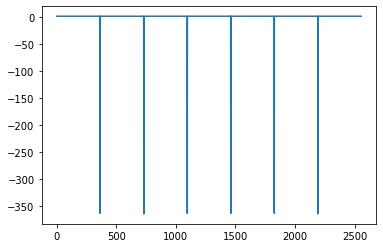

In [83]:
(custom_fourier_terms(weather) - custom_fourier_terms(weather).shift(1)).plot()

In [ ]:
custom_fourier_terms(weat)

<AxesSubplot:xlabel='date'>

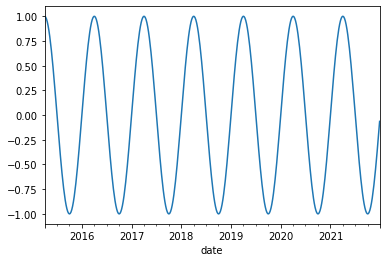

In [67]:
exog["sin(1,365.24)"].plot()

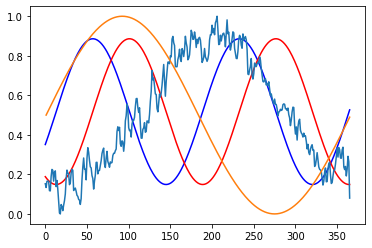

In [25]:
a = [sinfunc(x,A, w*2, p*1, c) for x in range(len(raw))]
b = [cosfunc(x,A, w*2, p*1, c) for x in range(len(raw))]
plt.plot(b, color="b")
plt.plot(a, color="r")
plt.plot(raw)
fourier_gen = Fourier(365.2422, order=1)
fourier = fourier_gen.in_sample(np.arange(1,366))
a = fourier["sin(1,365.24)"]
a = (a - a.min()) / (a.max() - a.min())
plt.plot(a)


In [58]:
fourier

NameError: name 'fourier' is not defined

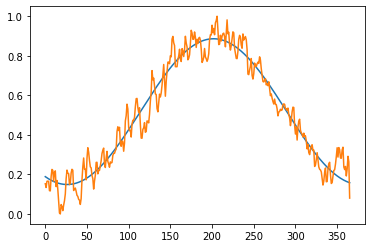

In [46]:
plt.plot(a)
plt.plot(raw)

<AxesSubplot:xlabel='date'>

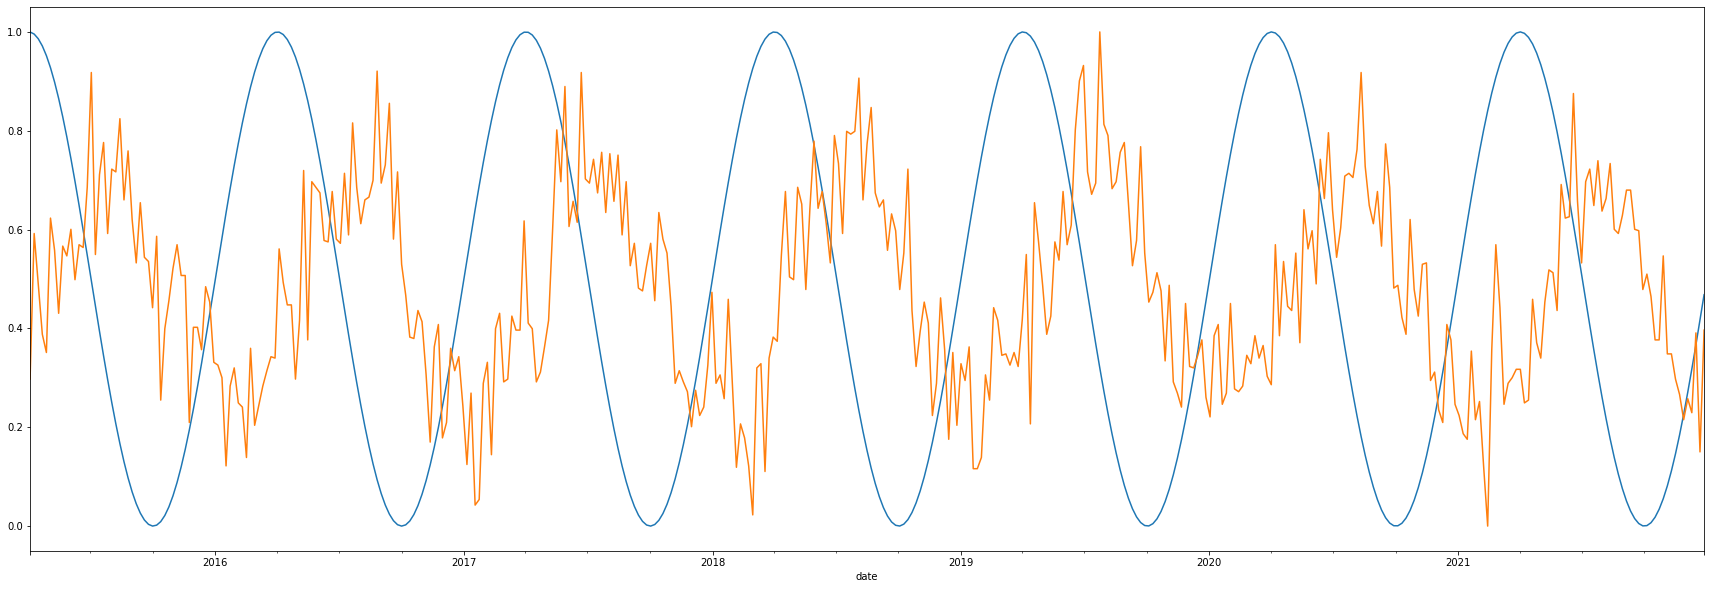

In [54]:
exog["sin(1,365.24)"].plot(figsize=(30,10))
#exog["cos(1,365.24)"].plot()
exog["temperature_0"].plot()
#exog["sin(2,365.24)"].plot()
#exog["cos(2,365.24)"].plot()

<AxesSubplot:xlabel='datetime'>

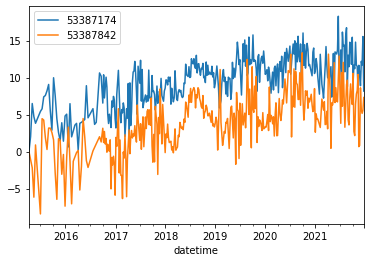

In [10]:
data["ASCE_088_03"].plot()

In [14]:
len(build_gloer_exog(data["ASCE_015_06"], stau, weather, fourier_order=0, external_timesteps=[], mean_period=0).columns)

0

<AxesSubplot:xlabel='datetime'>

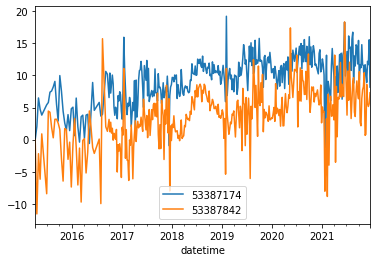

In [12]:
data["ASCE_088_03"].plot()

In [23]:
r = pickle.load(open("../saves_and_results/gloer_grid/results_stack.p", "rb"))

In [24]:
def results_to_pd(r):
    out = {}
    for x in r.keys():
        stack = []
        for y in r[x]:
            a = pd.concat(
            [pd.DataFrame(y[1]).T, pd.DataFrame(y[2]).T],
            axis=1,
        )
            a["params"] = str(y[0])
            stack.append(a)
        b = pd.concat(stack)
        b.reset_index(inplace=True)
        b.columns = ["P", "MSE_phase1","AIC_phase1", "MSE_phase2", "AIC_phase2","params"]
        out[x] = b
    return out

In [30]:
ex = {"Y": r}

In [31]:
transform = results_to_pd(ex)

In [32]:
check = transform["Y"]

In [41]:
check["P"].unique()

array([48605526, 48606219])

In [39]:
check[check["P"] == 48606219].sort_values(by="MSE_phase1")


,P,MSE_phase1,AIC_phase1,MSE_phase2,AIC_phase2,params
49,48606219,0.013221,-178.373288,0.002564,-157.445366,"[0, 0, 0, 2, array([0, 1, 2]), 0]"
51,48606219,0.013222,-174.364444,0.002562,-153.494548,"[0, 0, 0, 2, array([0, 1, 2]), 3]"
53,48606219,0.013231,-174.277279,0.002559,-153.560745,"[0, 0, 0, 2, array([0, 1, 2]), 6]"
103,48606219,0.013279,-228.605434,0.002569,-155.387454,"[0, 0, 1, 2, array([0, 1, 2]), 0]"
737,48606219,0.013281,-234.691365,0.003077,-137.269821,"[2, 0, 1, 1, array([0, 1, 2]), 6]"
...,...,...,...,...,...,...
1227,48606219,0.053025,-230.291618,0.004090,-149.790624,"[3, 1, 1, 2, array([0]), 3]"
1551,48606219,0.056335,-231.074652,0.004086,-145.853012,"[4, 1, 1, 2, array([0]), 3]"
1535,48606219,0.056473,-236.833384,0.003328,-139.296690,"[4, 1, 1, 1, array([0]), 6]"
909,48606219,0.063813,-217.696481,0.004197,-137.823897,"[2, 1, 1, 2, array([0, 1]), 3]"


In [40]:
check[check["P"] == 48606219].sort_values(by="MSE_phase2")


,P,MSE_phase1,AIC_phase1,MSE_phase2,AIC_phase2,params
1079,48606219,0.013614,-233.530197,0.002486,-163.718076,"[3, 0, 1, 2, array([0, 1, 2]), 6]"
1231,48606219,0.036676,-228.762399,0.002494,-148.313535,"[3, 1, 1, 2, array([0, 1]), 0]"
1347,48606219,0.013735,-238.156499,0.002502,-164.325977,"[4, 0, 0, 2, array([0, 1, 2]), 3]"
1025,48606219,0.013496,-234.819043,0.002505,-165.774643,"[3, 0, 0, 2, array([0, 1, 2]), 6]"
1075,48606219,0.013612,-235.788125,0.002506,-167.115379,"[3, 0, 1, 2, array([0, 1, 2]), 0]"
...,...,...,...,...,...,...
171,48606219,0.015817,-208.248013,0.025958,-118.516063,"[0, 1, 0, 0, array([0, 1]), 3]"
265,48606219,0.021603,-200.784154,0.026004,-144.177119,"[0, 1, 1, 2, array([0, 1, 2]), 0]"
927,48606219,0.022959,-226.425975,0.026929,-125.717136,"[2, 1, 2, 0, array([0, 1]), 3]"
925,48606219,0.021388,-229.831412,0.028564,-129.580910,"[2, 1, 2, 0, array([0, 1]), 0]"


In [ ]:
check[check["P"] == 10948750].sort_values(by="MSE_phase1")


In [115]:
import numpy as np
np.where(~(
    check[check["P"] == 10948750].sort_values(by="MSE_phase2").index
    == check[check["P"] == 10948750].sort_values(by="MSE_phase1").index
))

(array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
         40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
         53,  55,  56,  57,  58,  59,  60,  61,  62,  64,  65,  66,  67,
         68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,
         81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,
         94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106,
        107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119,
        120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132,
        133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145,
        146, 147, 148, 149, 151, 152, 153, 154, 155, 156, 157, 158, 159,
        160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172,
        173, 174, 175, 176, 177, 178, 179, 180, 181

In [55]:
a["ASCE_015_06"][12][0]

[0, 0, 0, 2, array([0]), 3]

In [61]:
a = pd.concat(
    [pd.DataFrame(r["ASCE_015_06"][12][1]).T, pd.DataFrame(r["ASCE_015_06"][12][1]).T],
    axis=1,
)
a["params"] = str(r["ASCE_015_06"][12][0])

In [62]:
a

,0,1,0,1,params
10948750,0.012647,-188.417763,0.012647,-188.417763,"[0, 0, 0, 2, array([0]), 3]"
10948843,0.010606,-212.346031,0.010606,-212.346031,"[0, 0, 0, 2, array([0]), 3]"
10948844,0.031149,-65.830977,0.031149,-65.830977,"[0, 0, 0, 2, array([0]), 3]"
10948988,0.017867,-141.421231,0.017867,-141.421231,"[0, 0, 0, 2, array([0]), 3]"


In [23]:
a["ASCE_015_06"][0][1].export()

[3,
 1,
 3,
 2,
 [0],
 6,
 {10948750: (0.0602750128652083, -107.69235262442598),
  10948843: (0.08734302999733413, -83.48155137330538),
  10948844: (0.023306955301202678, -93.96122469246208),
  10948988: (0.0037177227152184176, -121.22922399659305),
  53387174: (0.04109774591377542, -137.17378248945374),
  53387842: (0.002036747137734777, -153.23544899378982),
  2750741: (0.21665695288572345, -48.222876659149634),
  2751321: (0.15394794951471086, -45.02609455233012),
  2751322: (0.11760694693317975, -49.86523169301566),
  63343299: (0.2533710537463277, -48.277422810321895),
  63343437: (0.090230454979298, -1.8698047024153581),
  63343820: (0.02162276651614267, -25.293523230452777),
  63343978: (0.03163806185207228, -81.16815018460868),
  63344173: (0.10956950004320018, -52.88549861611385),
  7171370: (0.12194676748622556, -39.21278453902468),
  7171578: (0.16642537767354237, -21.525234641421903),
  7171972: (0.03223359477233584, -44.445566810595054),
  61281888: (0.07214582260204165, -

In [24]:
# Genereller Dataload. Nur einmal.

data, meta = load_gloer(remove_last_year=False, interpolate_endog=True)
stau, sicker = exog_gloer()
weather = weather_gloer()

# generate all model combos to test each time
combos = make_model_hp_list(F=[0])


/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [25]:
data["ASCE_015_06"]

,10948750,10948843,10948844,10948988
datetime,,,,
2015-04-04,0.0000,0.0000,0.0000,0.000
2015-04-10,-0.9155,0.3400,-3.8665,0.028
2015-04-16,-1.8310,0.6800,-7.7330,0.056
2015-04-22,-1.0915,1.0285,-4.0710,-0.797
2015-04-28,-0.3520,1.3770,-0.4090,-1.650
...,...,...,...,...
2021-12-04,2.1050,4.4850,-4.3330,0.640
2021-12-10,2.8770,0.1420,-3.4210,0.093
2021-12-16,2.7540,2.2150,-5.9030,2.203


In [3]:
data = {'ASCE_015_06': data["ASCE_015_06"]}

In [5]:
#go through all directions available
results = {}
for x in data.keys():
    print("Evaluation: " +  str(x))
        #iterate through every point.
    results[x] = find_best_order_gloer(combos=combos, endog=data[x], weather= weather, stau= stau, parallel=False)

Evaluation: ASCE_015_06
10948750
Y


/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)


10948843
Y


/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)


10948844
Y


...

/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


10948844
Y


/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


10948988
Y


/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency 6D will be used.
  self._init_dates(dates, freq)
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [9]:
results["ASCE_015_06"][0]

(<utils.baseline_tools.param_holder at 0x7fa6474c7c40>,
 <utils.baseline_tools.param_holder at 0x7fa6474c7c40>)

In [62]:

for x in data.keys():
    print(x)
    endog, exog = build_gloer_ds(data,stau,weather, direction=x)
    phases = prep_for_analysis(endog, exog)
    
            


ASCE_015_06
ASCE_088_03
VERTICAL
DESC_139_08
EASTWEST
DESC_037_04
DESC_139_07
ASCE_088_02


In [49]:
data, meta = load_gloer(remove_last_year=False, interpolate_endog=True)

In [51]:
data.keys()

dict_keys(['ASCE_015_06', 'ASCE_088_03', 'VERTICAL', 'DESC_139_08', 'EASTWEST', 'DESC_037_04', 'DESC_139_07', 'ASCE_088_02'])

In [22]:
phases["p_0"][0][0].values[:,0]

array([0.25875917, 0.19536768, 0.13197618, 0.183181  , 0.23438582,
       0.25301205, 0.27163828, 0.2640216 , 0.25640493, 0.22264922,
       0.18889351, 0.41407007, 0.63924664, 0.55380141, 0.46835618,
       0.51316761, 0.55797904, 0.60279047, 0.6476019 , 0.69241333,
       0.73722476, 0.566819  , 0.39641324, 0.43556987, 0.47472649,
       0.47680377, 0.47888104, 0.45125329, 0.42362554, 0.39599778,
       0.36837003, 0.34074228, 0.31311453, 0.37240341, 0.43169229,
       0.49098117, 0.55027005, 0.41773993, 0.2852098 , 0.3684739 ,
       0.45173799, 0.40067165, 0.34960532, 0.35327517, 0.35694502,
       0.35228269, 0.34762037, 0.34295804, 0.33829571, 0.33363338,
       0.32897106, 0.27821631, 0.22746157, 0.23111411, 0.23476665,
       0.23841919, 0.24207174, 0.1960601 , 0.15004847, 0.39014679,
       0.63024512, 0.42909569, 0.22794627, 0.24903061, 0.27011494,
       0.26696441, 0.26381388, 0.34621244, 0.428611  , 0.42023265,
       0.41185431, 0.3762983 , 0.34074228, 0.34340812, 0.34607

In [15]:
phases["p_0"][0][1].values.shape

(136, 8)

In [25]:
phases["p_0"][1][1]

,"sin(1,365.24)","cos(1,365.24)",temperature_0,temperature_1,temperature_mean_3_0,W_0,W_1,W_mean_3_0
date,,,,,,,,
2017-06-28,0.535285,0.001236,0.702550,0.917847,0.747783,0.848335,0.854912,0.850343
2017-07-04,0.483708,0.000255,0.694051,0.702550,0.695567,0.844225,0.848335,0.846228
2017-07-10,0.432305,0.004593,0.742210,0.694051,0.818719,0.838471,0.844225,0.840055
2017-07-16,0.381623,0.014205,0.674221,0.742210,0.674877,0.834361,0.838471,0.836488
2017-07-22,0.332200,0.028987,0.756374,0.674221,0.791133,0.830251,0.834361,0.831413
2017-07-28,0.284564,0.048783,0.634561,0.756374,0.705419,0.833950,0.830251,0.834294
2017-08-03,0.239221,0.073382,0.753541,0.634561,0.782266,0.830251,0.833950,0.831824
2017-08-09,0.196654,0.102522,0.657224,0.753541,0.706404,0.827785,0.830251,0.829218
2017-08-15,0.157315,0.135892,0.750708,0.657224,0.751724,0.831895,0.827785,0.831824


In [ ]:
def find_best_order_gloer(
    combos,
    ):
        
        # Runs some combos in parallel
        executor = Parallel(n_jobs=cpu_count()-1, backend='multiprocessing')
        tasks = (delayed(score_model)(location, direction ,combo, short,modeltype) for combo in combos)
        return executor(tasks)
        #return [score_model(location, direction ,combo) for combo in combos]

In [44]:
mod = sm.tsa.statespace.SARIMAX(
        phases["p_1"][0][0].values[:,0], phases["p_1"][0][1].values,
        order=(3,1,3), trend='c',use_exact_diffuse=True)

In [45]:
res = mod.fit(disp=False)

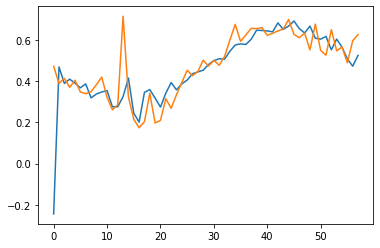

In [46]:
plt.plot(res.predict())
plt.plot(phases["p_1"][0][0].values[:,0])

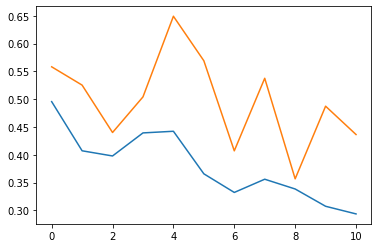

In [48]:
plt.plot(res.forecast(11, exog=phases["p_1"][1][1].values))
plt.plot(phases["p_1"][1][0].values[:,0])

In [ ]:
if len(out[1].columns) > 0:

    mod = sm.tsa.statespace.SARIMAX(
        train[0][:,n],
        train[1], order=(combo.p,combo.d,combo.q), trend='c',use_exact_diffuse=True)
else:
    mod = sm.tsa.statespace.SARIMAX(
        train[0][:,n], order=(combo.p,combo.d,combo.q), trend='c',use_exact_diffuse=True)
# sometimes we need to catch because fitting crashes
try:
    res = mod.fit(disp=False)
    score = score_arimax(res,test,n)

In [79]:
exog["W_0"][270:]

date
2019-09-10    299.8900
2019-09-16    299.8525
2019-09-22    299.7550
2019-09-28    299.7325
2019-10-04    299.8600
                ...   
2021-12-04    307.8800
2021-12-10    307.8800
2021-12-16    306.7430
2021-12-22    306.3600
2021-12-28    306.2800
Name: W_0, Length: 141, dtype: float64

<AxesSubplot:xlabel='date'>

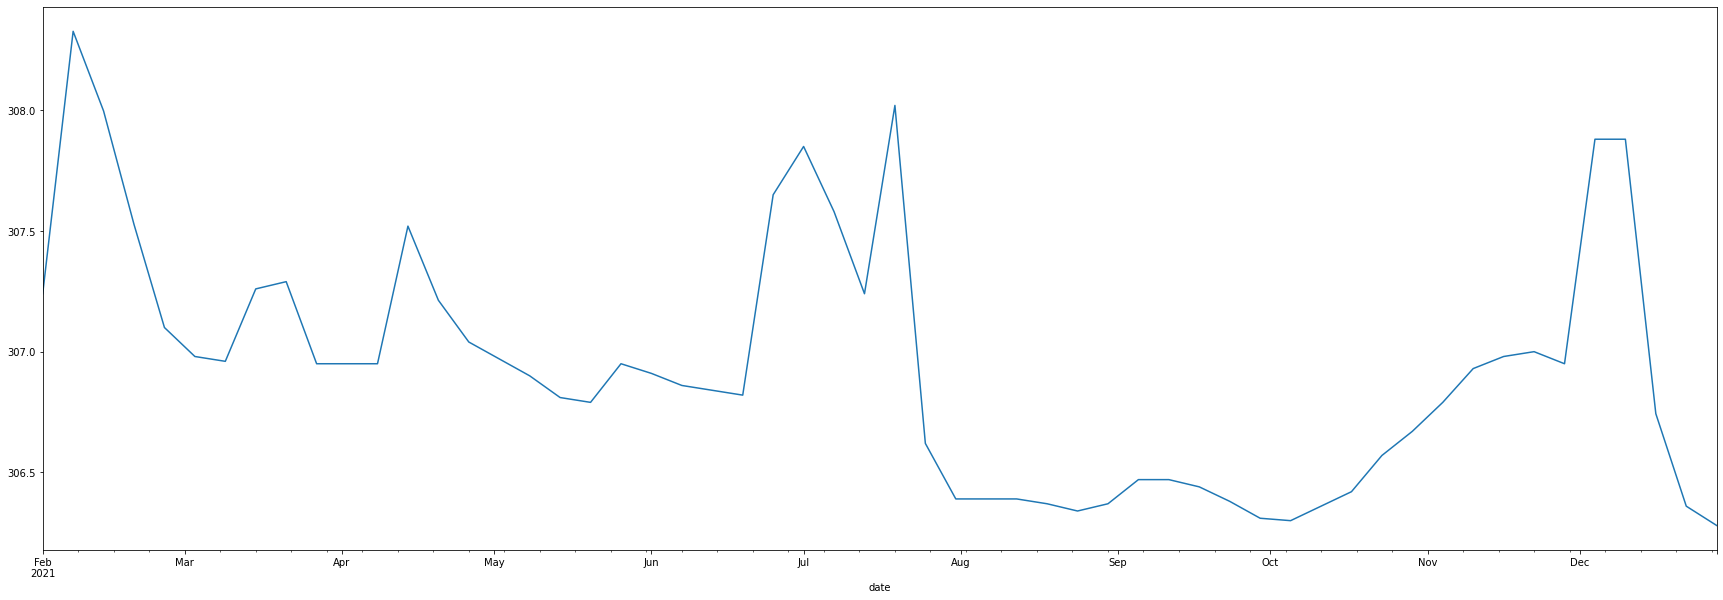

In [126]:
exog["W_0"][355:].plot(figsize=(30,10))

<AxesSubplot:xlabel='date'>

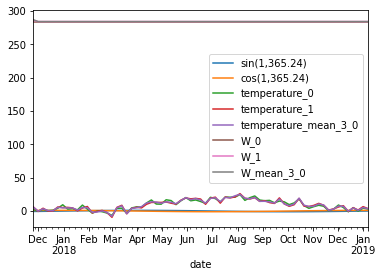

In [61]:
exog[exog["W_0"]< 290].plot()

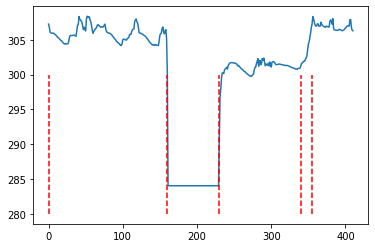

In [20]:
plt.plot(exog["W_0"].values)
plt.vlines(0, 280, 300, linestyles="dashed", color="r")
plt.vlines(160, 280, 300, linestyles="dashed", color="r")
plt.vlines(230, 280, 300, linestyles="dashed", color="r")
plt.vlines(340, 280, 300, linestyles="dashed", color="r")
plt.vlines(355, 280, 300, linestyles="dashed", color="r")

In [ ]:
# normalize etc. split in 3 intervals and train standard. 

In [29]:
stau, sicker = exog_gloer()


/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [25]:
weather[weather["date"] >= "2015-04-01"][["date", "temperature"]]

,date,temperature
90,2015-04-01,2.2
91,2015-04-02,2.9
92,2015-04-03,4.4
93,2015-04-04,3.2
94,2015-04-05,3.1
...,...,...
2551,2021-12-26,-0.2
2552,2021-12-27,4.2
2553,2021-12-28,6.7
2554,2021-12-29,7.3


In [34]:
stau[stau["date"] >= "2015-04-01"][["date", "W"]]

,date,W
2441,2015-04-01,306.640
2442,2015-04-02,306.940
2443,2015-04-03,307.160
2444,2015-04-04,307.240
2445,2015-04-05,307.230
...,...,...
5385,2023-04-21,307.790
5386,2023-04-22,307.710
5387,2023-04-23,307.617
5388,2023-04-24,307.520


In [36]:
921.3400000000001 / 3

307.1133333333334

<AxesSubplot:xlabel='date'>

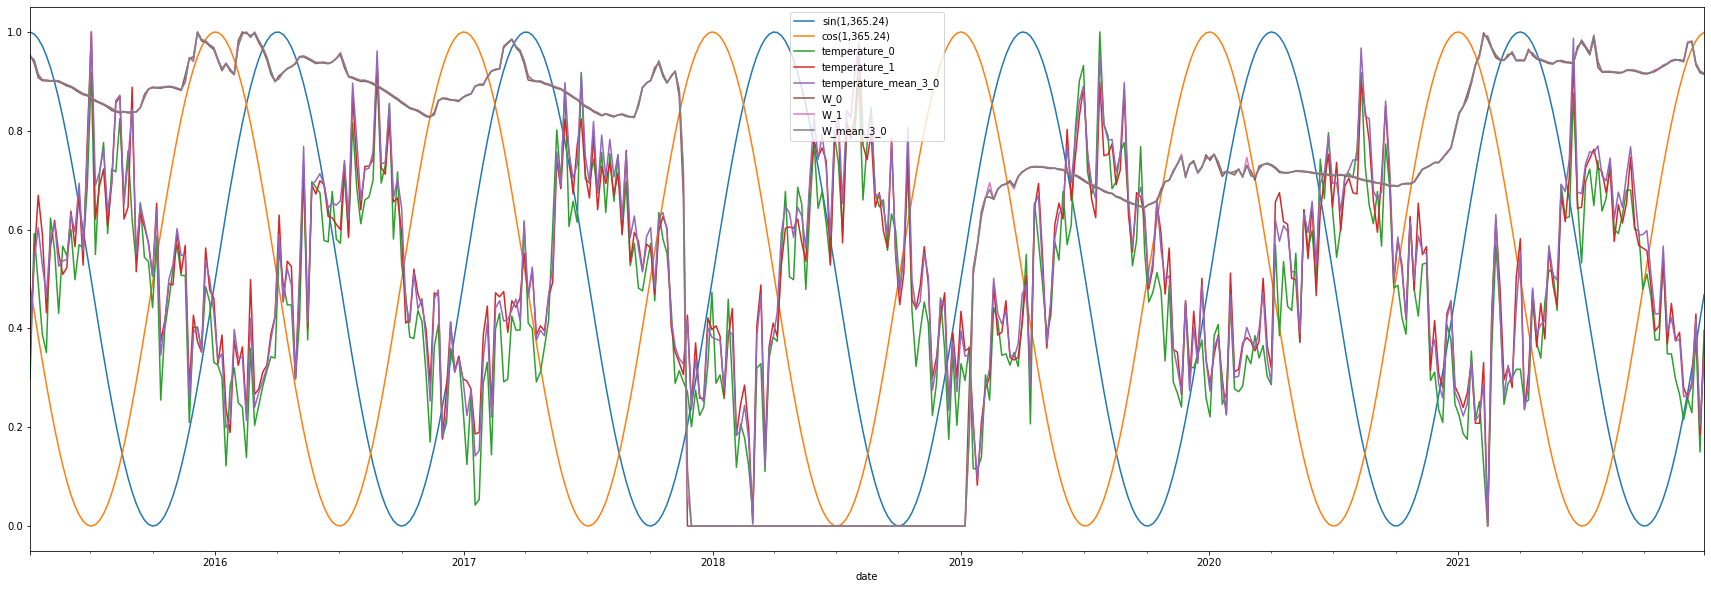

In [48]:
((exog- exog.min()) / (exog.max() - exog.min())).plot(figsize=(30,10))

In [13]:
fourier = fourier_gen.in_sample(data["ASCE_015_06"].reset_index()["datetime"].dt.dayofyear.values
)


<AxesSubplot:xlabel='date'>

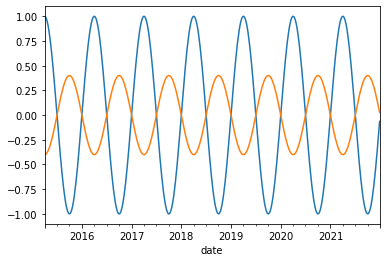

In [47]:
exog["sin(1,365.24)"].plot()
(exog["sin(1,365.24)"] * -0.4).plot()

In [185]:
def select_daily_exog(
    d, external_timesteps, timestamps, time_name="date", variable_name="W"
):
    stack = []
    for step in external_timesteps:
        move = d.copy()
        move["date"] = move[time_name].shift(-1 * step)
        move = move[move[time_name].isin(timestamps)]
        move = move[[time_name, variable_name]]
        move.rename(
            {variable_name: variable_name + "_" + str(step)}, axis=1, inplace=True
        )
        stack.append(move)
    exog = reduce(
        lambda left, right: pd.merge(left, right, on=["date"], how="outer"), stack
    )
    return exog

In [26]:
mean_window = stau.rolling(4).mean()
mean_window["date"] = stau.date
exog1 = select_daily_exog(mean_window, [0],data["ASCE_015_06"].index)


NameError: name 'stau' is not defined

In [201]:
exog1 = select_daily_exog(mean_window, [0],data["ASCE_015_06"].index)


In [215]:
exog1

,date,W_0
2444,2015-04-04,306.99500
2450,2015-04-10,306.99250
2456,2015-04-16,306.31500
2462,2015-04-22,305.98250
2468,2015-04-28,305.96500
...,...,...
4882,2021-12-04,307.61925
4888,2021-12-10,307.88000
4894,2021-12-16,307.06575
4900,2021-12-22,306.45000


In [213]:
stau[stau["date"] >= "2015-04-01"][:4].mean()

W    306.995
dtype: float64

In [203]:
exog1

,date,W_0
2444,2015-04-04,306.99500
2450,2015-04-10,306.99250
2456,2015-04-16,306.31500
2462,2015-04-22,305.98250
2468,2015-04-28,305.96500
...,...,...
4882,2021-12-04,307.61925
4888,2021-12-10,307.88000
4894,2021-12-16,307.06575
4900,2021-12-22,306.45000


<AxesSubplot:>

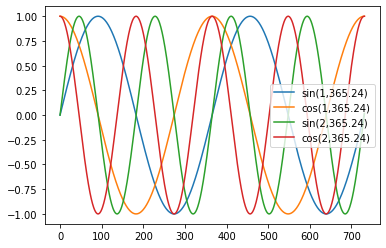

In [112]:
fourier_gen.in_sample(np.arange(366*2)).plot()

In [97]:
fourier = fourier_gen.in_sample(out[0].reset_index()["datetime"].dt.day_of_year.values)


out[0].reset_index()["datetime"].dt.day_of_year.values

<AxesSubplot:>

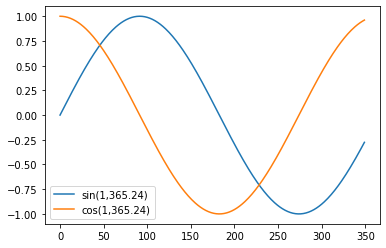

In [98]:
fourier.reset_index(drop=True).plot()

In [ ]:
fourier_gen = Fourier(365.2422, order=2)
fourier = fourier_gen.in_sample(ext.index)
fourier["datetime"] = ext.datetime
fourier = fourier[fourier["datetime"].isin(data.index)]
fourier.sort_values("datetime", inplace = True)

In [14]:
weather =  weather_gloer()

In [17]:
fourier_gen = Fourier(365.2422, order=2)
fourier = fourier_gen.in_sample(weather.index)
fourier["date"] = weather.date
fourier = fourier[fourier["date"].isin(data["ASCE_015_06"].index)]
fourier.sort_values("date", inplace = True)

In [18]:
fourier["date"] = weather.date
fourier = fourier[fourier["date"].isin(data["ASCE_015_06"].index)]
fourier.sort_values("date", inplace = True)

In [25]:
fourier

,"sin(1,365.24)","cos(1,365.24)","sin(2,365.24)","cos(2,365.24)",date
93,0.999578,-0.029059,-0.058094,-0.998311,2015-04-04
99,0.991264,-0.131895,-0.261485,-0.965208,2015-04-10
105,0.972399,-0.233326,-0.453772,-0.891118,2015-04-16
111,0.943183,-0.332274,-0.626790,-0.779188,2015-04-22
117,0.903928,-0.427685,-0.773193,-0.634171,2015-04-28
...,...,...,...,...,...
2529,-0.458617,0.888634,-0.815085,0.579341,2021-12-04
2535,-0.364617,0.931158,-0.679032,0.734109,2021-12-10
2541,-0.266736,0.963770,-0.514144,0.857704,2021-12-16
2547,-0.166016,0.986123,-0.327424,0.944878,2021-12-22


In [23]:
fourier

,"sin(1,365.24)","cos(1,365.24)","sin(2,365.24)","cos(2,365.24)",date
93,0.999578,-0.029059,-0.058094,-0.998311,2015-04-04
99,0.991264,-0.131895,-0.261485,-0.965208,2015-04-10
105,0.972399,-0.233326,-0.453772,-0.891118,2015-04-16
111,0.943183,-0.332274,-0.626790,-0.779188,2015-04-22
117,0.903928,-0.427685,-0.773193,-0.634171,2015-04-28
...,...,...,...,...,...
2529,-0.458617,0.888634,-0.815085,0.579341,2021-12-04
2535,-0.364617,0.931158,-0.679032,0.734109,2021-12-10
2541,-0.266736,0.963770,-0.514144,0.857704,2021-12-16
2547,-0.166016,0.986123,-0.327424,0.944878,2021-12-22


In [53]:
fourier_gen = Fourier(365.2422, order=2)


In [55]:
fourier = fourier_gen.in_sample(np.arange(300))


<AxesSubplot:>

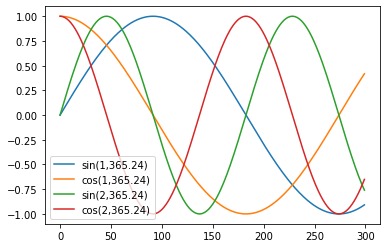

In [57]:
fourier.plot()

In [9]:
data, meta = load_gloer(remove_last_year=False, interpolate_endog=True)

<AxesSubplot:>

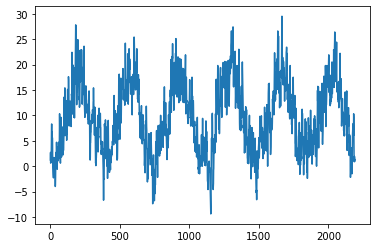

In [45]:
weather["temperature"].plot()

In [22]:
stau

,date,W
0,2008-07-25,305.500
1,2008-07-26,305.490
2,2008-07-27,305.620
3,2008-07-28,305.640
4,2008-07-29,305.640
...,...,...
5385,2023-04-21,307.790
5386,2023-04-22,307.710
5387,2023-04-23,307.617
5388,2023-04-24,307.520


In [39]:
join = data["EASTWEST"].merge(stau, left_index=True, right_on="date").drop(columns=["date"])


<AxesSubplot:>

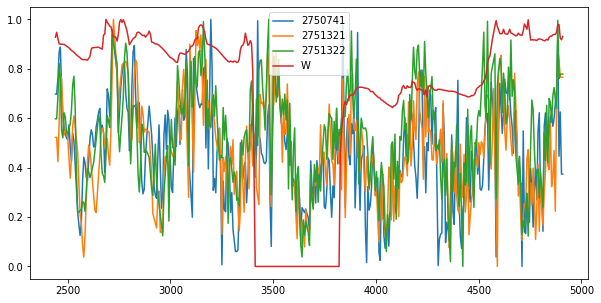

In [40]:
((join - join.min())  / (join.max() - join.min())).plot(figsize=(10, 5))

In [2]:
# oh boy doesnt seem like there is much going on :)

/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [ ]:
# Intervention

# Find Model in the same way as before for before middle and after the event
# Compare residual, and parameter values. 
# Do some granger causality analysis with all the variables? I guess that should involve all the models?
# Analyze if there is a difference between the directions? 


# Sickerwasser: 

# Run the full pipeline of the model search (include other models here.)
# Include sickerwasser and check if it has some predictive values. Use all the 



